# Phase 2: Preprocessing & EDA
ในขั้นตอนนี้เราจะสำรวจข้อมูล (Exploratory Data Analysis) และเตรียมรูปภาพ (Preprocessing) ให้พร้อมสำหรับ AI ครับ

### 1. Import Libraries
เราจะใช้เครื่องมือพื้นฐานคือ `os` (จัดการไฟล์), `pandas` (ตารางข้อมูล) และ `matplotlib` (วาดกราฟ/โชว์รูป)

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ตั้งค่าฟอนต์ภาษาไทยสำหรับ Mac (Thonburi เป็นฟอนต์มาตรฐานที่มีทุกเครื่อง)
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False # แก้ไขเรื่องเครื่องหมายลบแสดงผลผิดพลาด

print("Libraries Loaded with Thai Font Support!")

Libraries Loaded with Thai Font Support!


### 2. ตรวจสอบจำนวนข้อมูล (Data Inventory)
เราจะไปนับว่าในโฟลเดอร์ `dataset` ของเรา มีรูปตัวเลขละกี่ใบ

  เลขไทย  จำนวนรูป
0     65        33
1     66        31
2     67        33
3     68        30
4     69        31
5     70        30


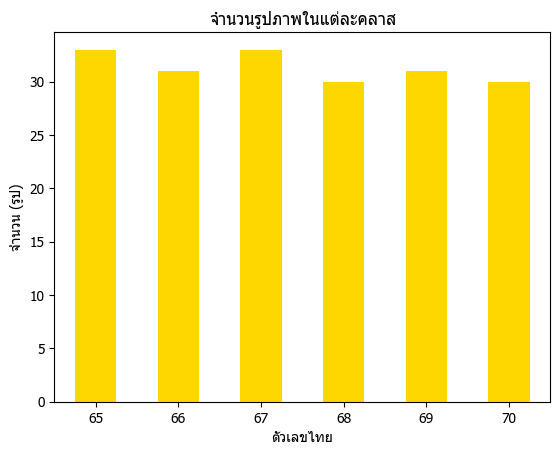

In [2]:
dataset_path = 'dataset'
classes = sorted(os.listdir(dataset_path))

data_count = []
for char_class in classes:
    if char_class.startswith('.'): continue # ข้ามไฟล์ซ่อนเช่น .DS_Store
    path = os.path.join(dataset_path, char_class)
    count = len(os.listdir(path))
    data_count.append({'เลขไทย': char_class, 'จำนวนรูป': count})

df = pd.DataFrame(data_count)
print(df)

# วาดกราฟให้เห็นภาพง่ายๆ
df.plot(kind='bar', x='เลขไทย', y='จำนวนรูป', color='gold', legend=False)
plt.title('จำนวนรูปภาพในแต่ละคลาส')
plt.xlabel('ตัวเลขไทย')
plt.ylabel('จำนวน (รูป)')
plt.xticks(rotation=0) # ให้ชื่อแกน x ตั้งตรง
plt.show()

### 3. ดูตัวอย่างรูปภาพ (Sample Visualization)
ลองดึงรูปแรกของแต่ละคลาสมาโชว์ดูว่าหน้าตาเป็นอย่างไร

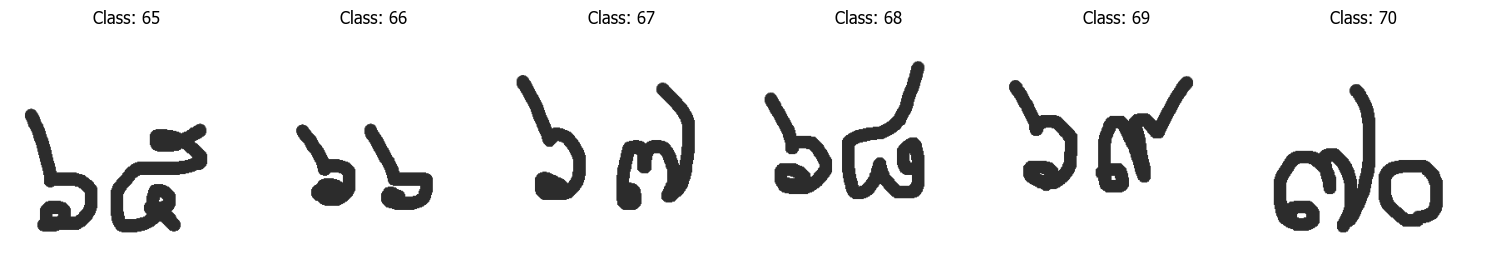

In [3]:
plt.figure(figsize=(15, 5))

for i, char_class in enumerate(df['เลขไทย']):
    class_path = os.path.join(dataset_path, char_class)
    # ดึงรายชื่อไฟล์รูปภาพใบแรก
    img_name = [f for f in os.listdir(class_path) if not f.startswith('.')][0]
    img_path = os.path.join(class_path, img_name)
    
    # เปิดรูปด้วย PIL
    img = Image.open(img_path)
    
    # วางรูปในตำแหน่งต่างๆ (1 แถว, n คอลัมน์)
    plt.subplot(1, len(df), i + 1)
    plt.imshow(img)
    plt.title(f"Class: {char_class}")
    plt.axis('off') # ปิดเส้นแกน x, y จะได้เห็นรูปชัดๆ

plt.tight_layout()
plt.show()

### 4. การเตรียมภาพ (Image Preprocessing)
ในส่วนนี้เราจะทำการ 'ทำความสะอาดและปรับขนาด' วัตถุดิบของเราครับ โดยเราจะทำ 2 อย่างหลักๆ:
1. **Grayscale (L):** แปลงภาพเป็นขาวดำ เพราะโมเดลไม่จำเป็นต้องใช้สีในการแยกแยะตัวเลข (ลดความซับซ้อน)
2. **Resize (8x8):** ปรับภาพทุกใบให้มีขนาดเท่ากันคือ 8x8 พิกเซล เพื่อให้โมเดลพื้นฐานเรียนรู้ได้ง่ายและไม่ต้องรับข้อมูลที่เยอะเกินไป

มาลองทำกับรูปตัวอย่าง 1 รูปกันก่อนครับ

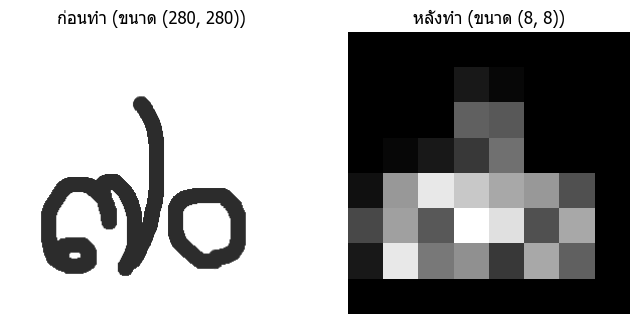

In [4]:
# ดึงรูปตัวอย่างมา 1 รูป (จากที่เราโหลดไว้ตอนแรก)
sample_img = img

# 1. แปลงเป็นขาวดำ (L mode ใน PIL)
gray_img = sample_img.convert('L')

# 2. ปรับขนาดเป็น 8x8 (ลดรายละเอียดให้โมเดลพื้นฐานโฟกัสรูปร่างหลักได้ดีขึ้น)
resized_img = gray_img.resize((8, 8))

# เปรียบเทียบ ก่อน-หลัง
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title(f"ก่อนทำ (ขนาด {sample_img.size})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(resized_img, cmap='gray')
plt.title(f"หลังทำ (ขนาด {resized_img.size})")
plt.axis('off')

plt.show()

### 5. นำไปใช้กับข้อมูลทั้งหมด (Apply to All Data)
ตอนนี้เราจะสร้างโฟลเดอร์ใหม่ชื่อ `dataset_cleaned` และวนลูปเอารูปทั้งหมดไปทำ Preprocessing แล้วเซฟเก็บไว้ครับ

In [5]:
output_dir = 'dataset_cleaned'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

processed_count = 0

for char_class in df['เลขไทย']:
    class_path = os.path.join(dataset_path, char_class)
    out_class_path = os.path.join(output_dir, char_class)
    
    if not os.path.exists(out_class_path):
        os.makedirs(out_class_path)
        
    for img_name in os.listdir(class_path):
        if img_name.startswith('.'): continue
        
        img_path = os.path.join(class_path, img_name)
        out_img_path = os.path.join(out_class_path, img_name)
        
        # เปิดภาพ -> แปลงขาวดำ -> ปรับขนาด -> เซฟ
        img_process = Image.open(img_path)
        img_process = img_process.convert('L').resize((8, 8))
        img_process.save(out_img_path)
        processed_count += 1

print(f"ทำ Preprocessing เสร็จสิ้น! บันทึกภาพทั้งหมด {processed_count} รูป ไปที่โฟลเดอร์ '{output_dir}'")

ทำ Preprocessing เสร็จสิ้น! บันทึกภาพทั้งหมด 188 รูป ไปที่โฟลเดอร์ 'dataset_cleaned'


### 6. แปลงรูปภาพเป็นตาราง (Data Preparation & Flattening)
คอมพิวเตอร์ไม่รู้จัก 'รูปภาพ' ครับ มันรู้จักแต่ 'ตัวเลข' 
เราจะต้องทำ 3 ขั้นตอนย่อยในส่วนนี้ครับ:
1. **กลับสี (Invert):** ให้พื้นหลังเป็นสีดำ (0) และตัวเลขเป็นสีขาว (255) เพื่อให้ AI โฟกัสเฉพาะรอยหมึก
2. **ปรับสเกล (Normalization):** หารด้วย 255 เพื่อให้ค่าตัวเลขอยู่ในช่วง 0 ถึง 1 (โมเดลจะคำนวณได้ดีขึ้น)
3. **แผ่รูปภาพ (Flatten):** เอาภาพขนาด 8x8 มาแผ่ออกให้เป็นแถวยาวๆ 1 แถวที่มี 64 ตัวเลข (8 * 8 = 64)

จากนั้นเราจะนำไปเก็บในตาราง (DataFrame) และเซฟเป็นไฟล์ `.csv` เพื่อเตรียมส่งเข้าโมเดล AI ในขั้นตอนถัดไปครับ

In [6]:
import numpy as np

data_flat = []

# วนลูปอ่านรูปภาพที่ทำความสะอาดแล้ว
for char_class in df['เลขไทย']:
    class_path = os.path.join(output_dir, char_class)
    for img_name in os.listdir(class_path):
        if img_name.startswith('.'): continue
        
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        
        # แปลงรูปเป็นเมทริกซ์ตัวเลข
        img_array = np.array(img)
        
        # ขั้นตอนที่ 1: กลับสีภาพ (Invert) ให้พื้นหลังเป็น 0 ตัวเลขเป็น 255
        img_inverted = 255 - img_array
        
        # ขั้นตอนที่ 2: ปรับสเกล (Normalization) ให้ค่าอยู่ระหว่าง 0-1
        img_normalized = img_inverted / 255.0
        
        # ขั้นตอนที่ 3: คลี่รูปจาก 2 มิติ (8x8) เป็นมิติเดียว (ยาว 64)
        img_flat = img_normalized.flatten()
        
        # เอาตัวเลขทั้ง 64 ตัว ใส่ไว้ในลิสต์ แล้วต่อท้ายด้วย 'คำตอบ' (label)
        row = list(img_flat)
        row.append(char_class) # ใส่ label ว่ารูปนี้คือเลขอะไร
        
        data_flat.append(row)

# สร้างชื่อคอลัมน์: pixel_1, pixel_2, ..., pixel_64, และคอลัมน์สุดท้ายชื่อ label
columns = [f"pixel_{i+1}" for i in range(8*8)] + ["label"]

# แปลงเป็นตาราง Pandas
df_ml = pd.DataFrame(data_flat, columns=columns)

# ตรวจสอบหน้าตาของตาราง
print("ขนาดของตาราง:", df_ml.shape)
display(df_ml.head())

# บันทึกเป็นไฟล์ CSV
csv_filename = "dataset_prepared.csv"
df_ml.to_csv(csv_filename, index=False)
print(f"\nบันทึกข้อมูลตารางลงไฟล์ '{csv_filename}' เรียบร้อยแล้ว!")

ขนาดของตาราง: (188, 65)


,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,pixel_10,...,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,pixel_64,label
0,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000000,...,1.0,1.0,0.996078,1.0,1.0,0.992157,1.0,1.0,1.0,65
1,0.992157,1.000000,1.0,1.0,1.0,1.0,1.0,0.976471,0.937255,0.976471,...,1.0,1.0,1.000000,1.0,1.0,1.000000,1.0,1.0,1.0,65
2,0.992157,0.941176,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,0.925490,...,1.0,1.0,1.000000,1.0,1.0,1.000000,1.0,1.0,1.0,65
3,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.000000,...,1.0,1.0,1.000000,1.0,1.0,1.000000,1.0,1.0,1.0,65
4,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.984314,0.996078,...,1.0,1.0,1.000000,1.0,1.0,1.000000,1.0,1.0,1.0,65



บันทึกข้อมูลตารางลงไฟล์ 'dataset_prepared.csv' เรียบร้อยแล้ว!


## Phase 3: Model Training (การสอน AI)
ตอนนี้เรามีข้อมูลพร้อมแล้ว! เราจะมาสอน AI ให้แยกแยะตัวเลขกันครับ โดยเราจะใช้อัลกอริทึม **Random Forest (ป่าสุ่ม)** ซึ่งเป็นการเอา Decision Tree หลายๆ ต้นมาช่วยกันโหวต (เทคนิคนี้อยู่ในกลุ่ม Decision Tree แบบต่อยอด และใช้ได้ในวิชาเรียนครับ) การที่เราลดขนาดภาพเหลือ 8x8 จะช่วยให้โมเดลโฟกัสรูปร่างหลักและไม่ถูกรบกวนด้วยรายละเอียดเล็กๆ น้อยๆ ทำให้ทายแม่นขึ้นมหาศาลครับ!

In [7]:
from sklearn.model_selection import train_test_split

# 1. อ่านข้อมูลที่เราเตรียมไว้
df_train = pd.read_csv('dataset_prepared.csv')

# 2. แยกข้อสอบ (Features) และ เฉลย (Labels)
# X คือ พิกเซลทั้ง 64 ช่อง (ข้อสอบ)
X = df_train.drop('label', axis=1)
# y คือ ตัวเลข 65-70 (เฉลย)
y = df_train['label']

# 3. แบ่งข้อมูลเป็น 2 กอง: 
# - กองที่ 1: ไว้สอน AI (Train 80%)
# - กองที่ 2: ไว้สอบเก็บคะแนน AI (Test 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"รูปภาพสำหรับสอน (Train): {len(X_train)} รูป")
print(f"รูปภาพสำหรับทดสอบ (Test): {len(X_test)} รูป")

รูปภาพสำหรับสอน (Train): 150 รูป
รูปภาพสำหรับทดสอบ (Test): 38 รูป


### เริ่มการสอน (Training) และ ตรวจข้อสอบ (Evaluation)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from datetime import datetime

# สร้าง 'สมอง' ของ AI (ใช้ Random Forest จำนวน 100 ต้น)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# ให้ AI เรียนรู้จากข้อมูล Train (ป้อนข้อสอบ + เฉลย)
model.fit(X_train, y_train)
print("AI เรียนรู้เสร็จแล้ว! 🧠\n")

# ให้ AI ลองทำข้อสอบชุด Test (รูปที่ไม่เคยเห็นมาก่อน)
y_pred = model.predict(X_test)

# ตรวจข้อสอบว่าทำถูกกี่เปอร์เซ็นต์
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 ความแม่นยำ (Accuracy): {accuracy * 100:.2f}%")

# เพิ่มข้อมูลพิเศษเข้าไปในโมเดล เพื่อให้หน้า Admin ดึงไปแสดงผลได้
model.algorithm_name_ = 'Random Forest (100 Trees)'
model.test_accuracy_ = f'{accuracy * 100:.2f}%'
model.training_date_ = datetime.now().strftime('%d %b %Y, %H:%M')
model.training_samples_ = str(len(X_train))

# ดูรายงานแบบละเอียด
print("\n📊 รายงานผลการสอบ (Classification Report):")
print(classification_report(y_test, y_pred))

AI เรียนรู้เสร็จแล้ว! 🧠

🎯 ความแม่นยำ (Accuracy): 92.11%

📊 รายงานผลการสอบ (Classification Report):
              precision    recall  f1-score   support

          65       1.00      0.88      0.93         8
          66       1.00      1.00      1.00         5
          67       1.00      0.86      0.92         7
          68       0.80      0.80      0.80         5
          69       0.71      1.00      0.83         5
          70       1.00      1.00      1.00         8

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.91        38
weighted avg       0.94      0.92      0.92        38



### บันทึกสมอง AI (Save Model)
เมื่อเราพอใจกับความแม่นยำแล้ว (เป้าหมายคือ >= 80%) เราจะเซฟโมเดลนี้เก็บไว้เป็นไฟล์ `.joblib` เพื่อเอาไปต่อกับระบบ Web Backend ใน Phase ถัดไปครับ

In [ ]:
import joblib

# ตั้งชื่อไฟล์โมเดล
model_filename = "handwriting_model.joblib"

# บันทึกไฟล์
joblib.dump(model, model_filename)

print(f"บันทึกโมเดลลงไฟล์ '{model_filename}' เรียบร้อย")

💾 บันทึกโมเดลลงไฟล์ 'handwriting_model.joblib' เรียบร้อย พร้อมลุย Phase 4!
